Length of file = 136925
Length of file = 118442


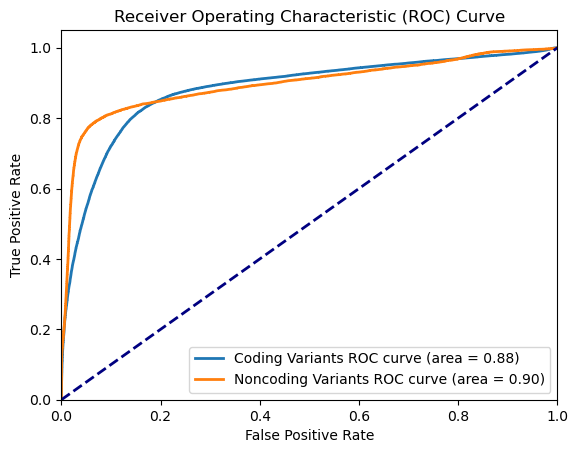

In [2]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve_from_file(delta_scores_path, label="Benchmark"):
    """
    Load delta scores and labels from a CSV file, compute ROC-AUC, and plot the ROC curve.
    """
    # Load delta scores and labels from the CSV file
    results_df = pd.read_csv(delta_scores_path)
    print(f"Length of file = {len(results_df)}")
    delta_scores = -results_df["delta_score"]
    labels = results_df["label"]
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(labels, delta_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot the ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{label} ROC curve (area = {roc_auc:.2f})')

# Plot ROC curves for coding and noncoding variants
plt.figure()

# Coding variants
plot_roc_curve_from_file(
    "./hg38_dataset/DeltaScores_coding_with_labels.csv", 
    label="Coding Variants"
)

# Noncoding variants
plot_roc_curve_from_file(
    "./hg38_dataset/DeltaScores_noncoding_with_labels.csv", 
    label="Noncoding Variants"
)

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set plot properties
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig(r'./hg38_dataset/ROC_AUC.jpg')

# Show the plot
plt.show()